In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import fsolve
%run IPR.ipynb
%run VLP.ipynb

In [19]:
# Effect of Pwh
def Pwh_effect(Pwh_new):
    Pwf_array_VLP1 = Poettmann_and_Carpenter_Method(Pwh_new, T, d, API, GLR, Bw, fo, fw, Yg, Yo, Yw, Qo_array_VLP, depth)
    Pwf_predictator_VLP1 = splrep(Qo_array_VLP, Pwf_array_VLP1, k=3, s=9)
    Pwf_predicted_VLP1 = splev(Qo_array_VLP, Pwf_predictator_VLP )

    print(f"New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = ({calculate_intersection(Pwf_predictator_VLP1, Pwf_predictator_IPR, initial_guess=500.0)[0]:.2f}, {calculate_intersection(Pwf_predictator_VLP1, Pwf_predictator_IPR, initial_guess=500.0)[1]:.2f})")

    # Create the plot
    plt.plot( Qo_array_VLP, Pwf_predicted_VLP, 'o', label=f'VLP with Pwh={Pwh_VLP} psi', color='green')
    plt.plot(Qo_array_VLP, Pwf_predicted_VLP, '-', color='green')
    plt.plot(Qo_array_VLP, Pwf_array_VLP1, '--',label=f'VLP with Pwh={Pwh_new} psi', color='maroon')
    plt.plot( Qo_array_IPR, Pwf_array_IPR, 'o', label=f'IPR', color='crimson')
    plt.plot(Qo_array_IPR, Pwf_predicted_IPR, '-', color='crimson')

    # Set the y-axis limits to start at the bottom of the well till top (inverted)
    plt.ylim(0, )
    plt.xlim(0, )

    # Customize labels and title
    plt.xlabel('Qo (STB/day) ')
    plt.ylabel('Pwf (psi)')
    plt.title('Inflow and Outflow Relationships')

    # Add a horizontal line at y=0 for better visualization of mirrored effect (optional)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

    # Adjust legend placement (optional)
    plt.legend(loc='upper right')

    # Display the plot
    plt.grid(True)
    plt.show()

New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = (970.24, 515.87)


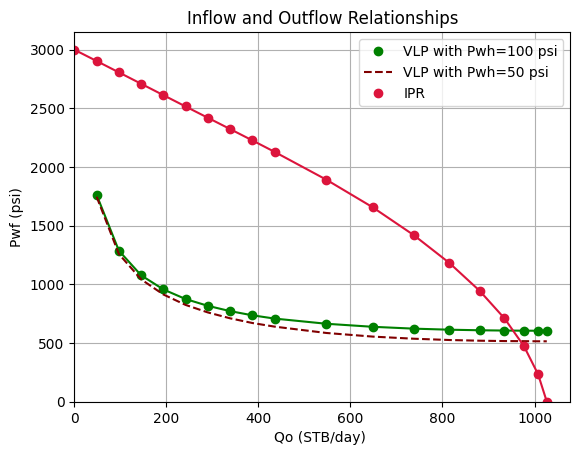

In [20]:
Pwh_effect(50)